## Setup & Authentication

Before running any experiments, you need to configure your API key.

**Steps to configure:**
1. **Register** and log in to the QpiAI QCloud platform at [https://qcloud.qpiai.tech](https://qcloud.qpiai.tech/)

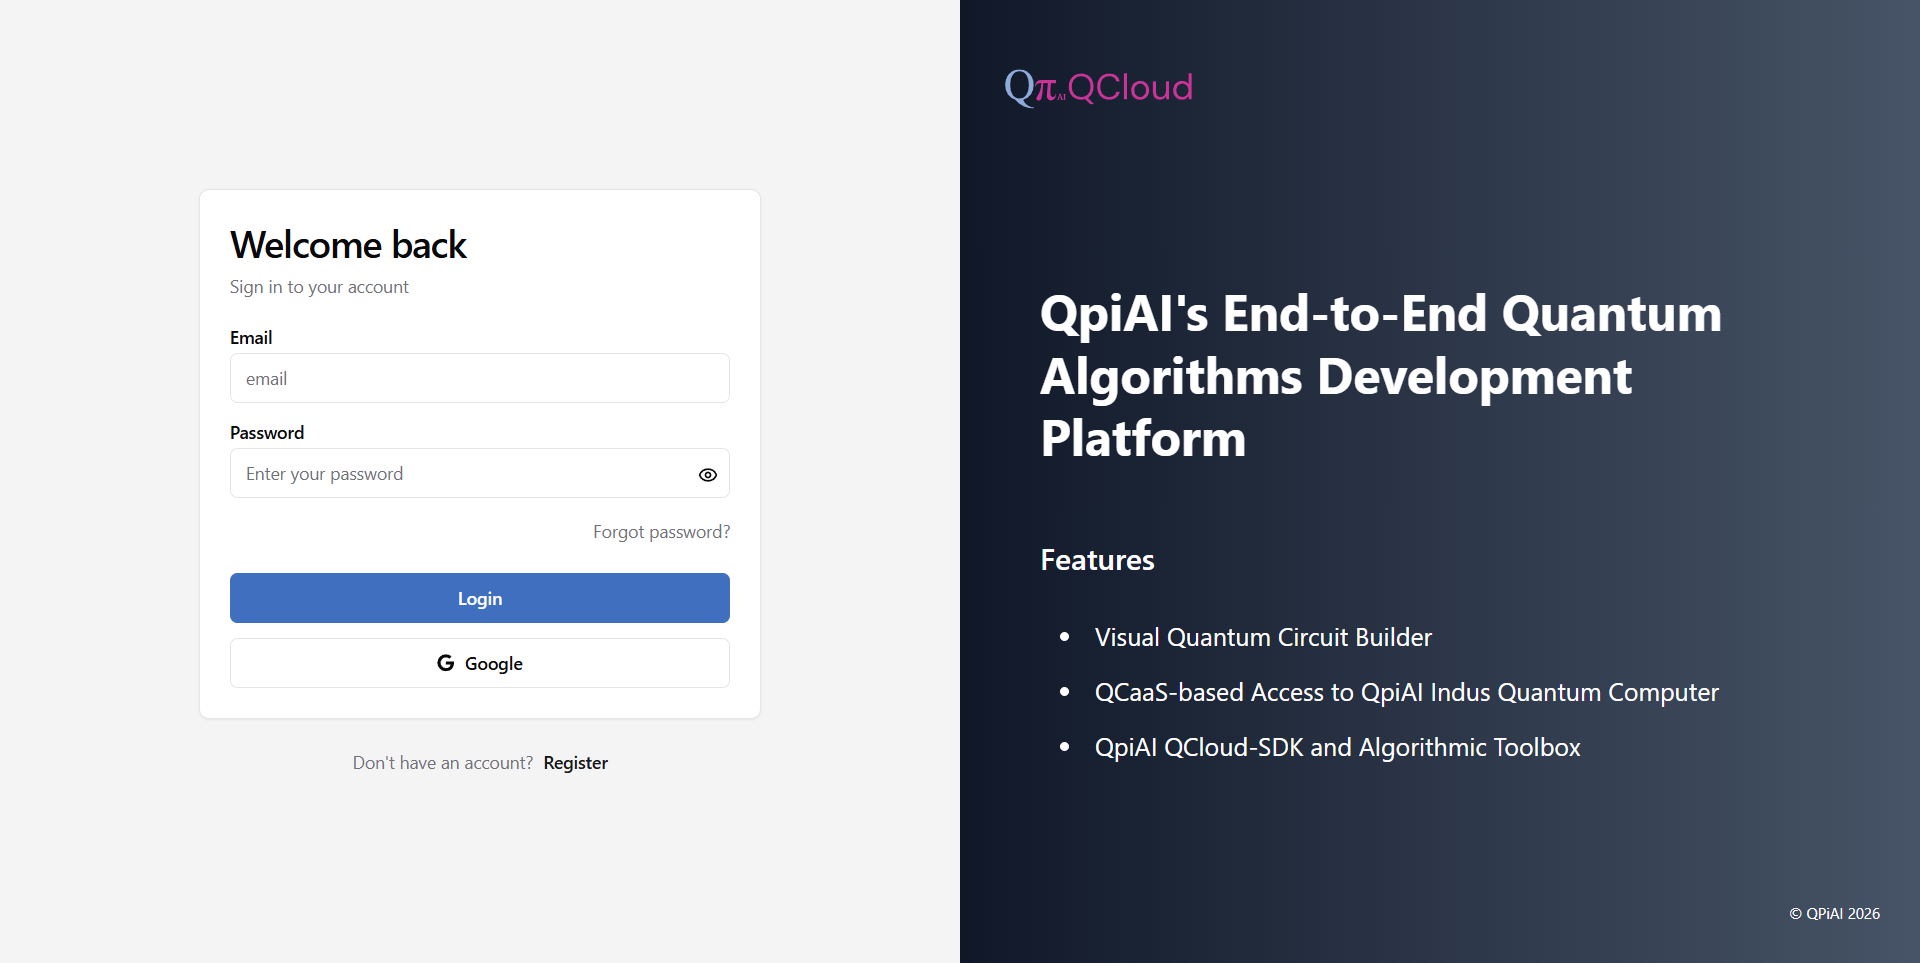

2. Go to the dropdown menu in the top right corner and click on **API Token**

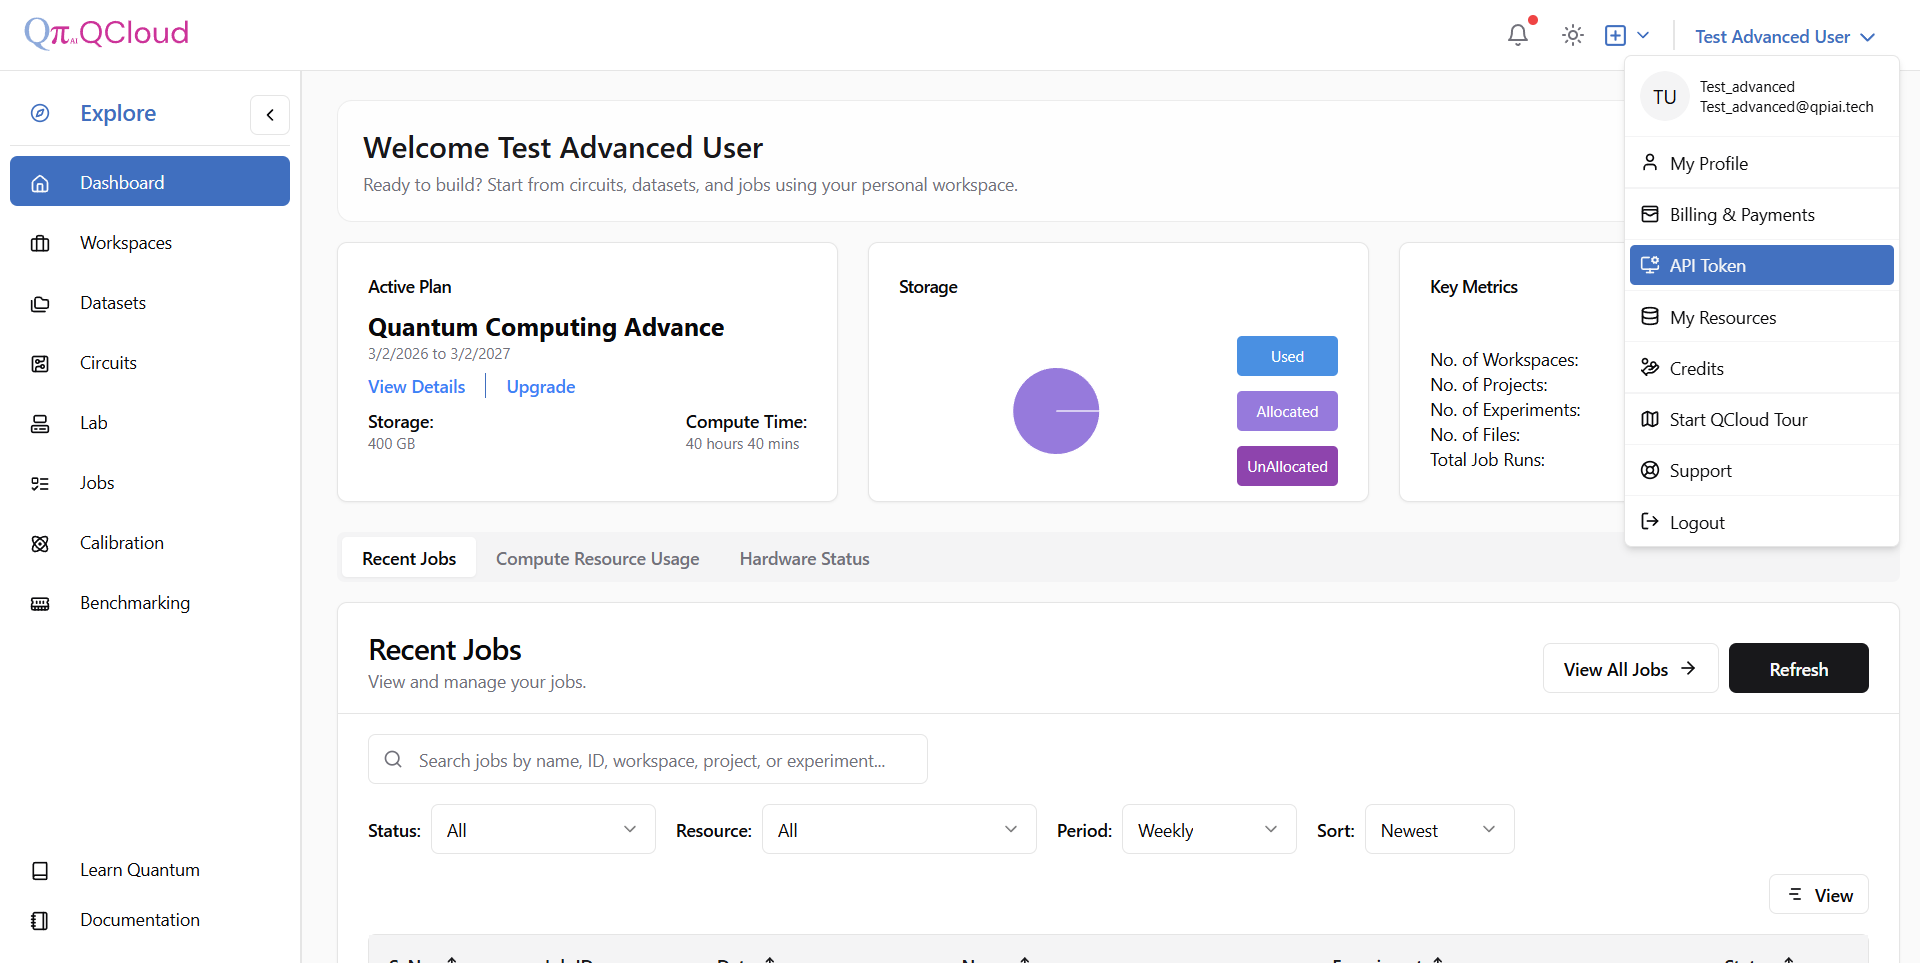

3. Under the **Tokens** section, copy your *Main API Token*

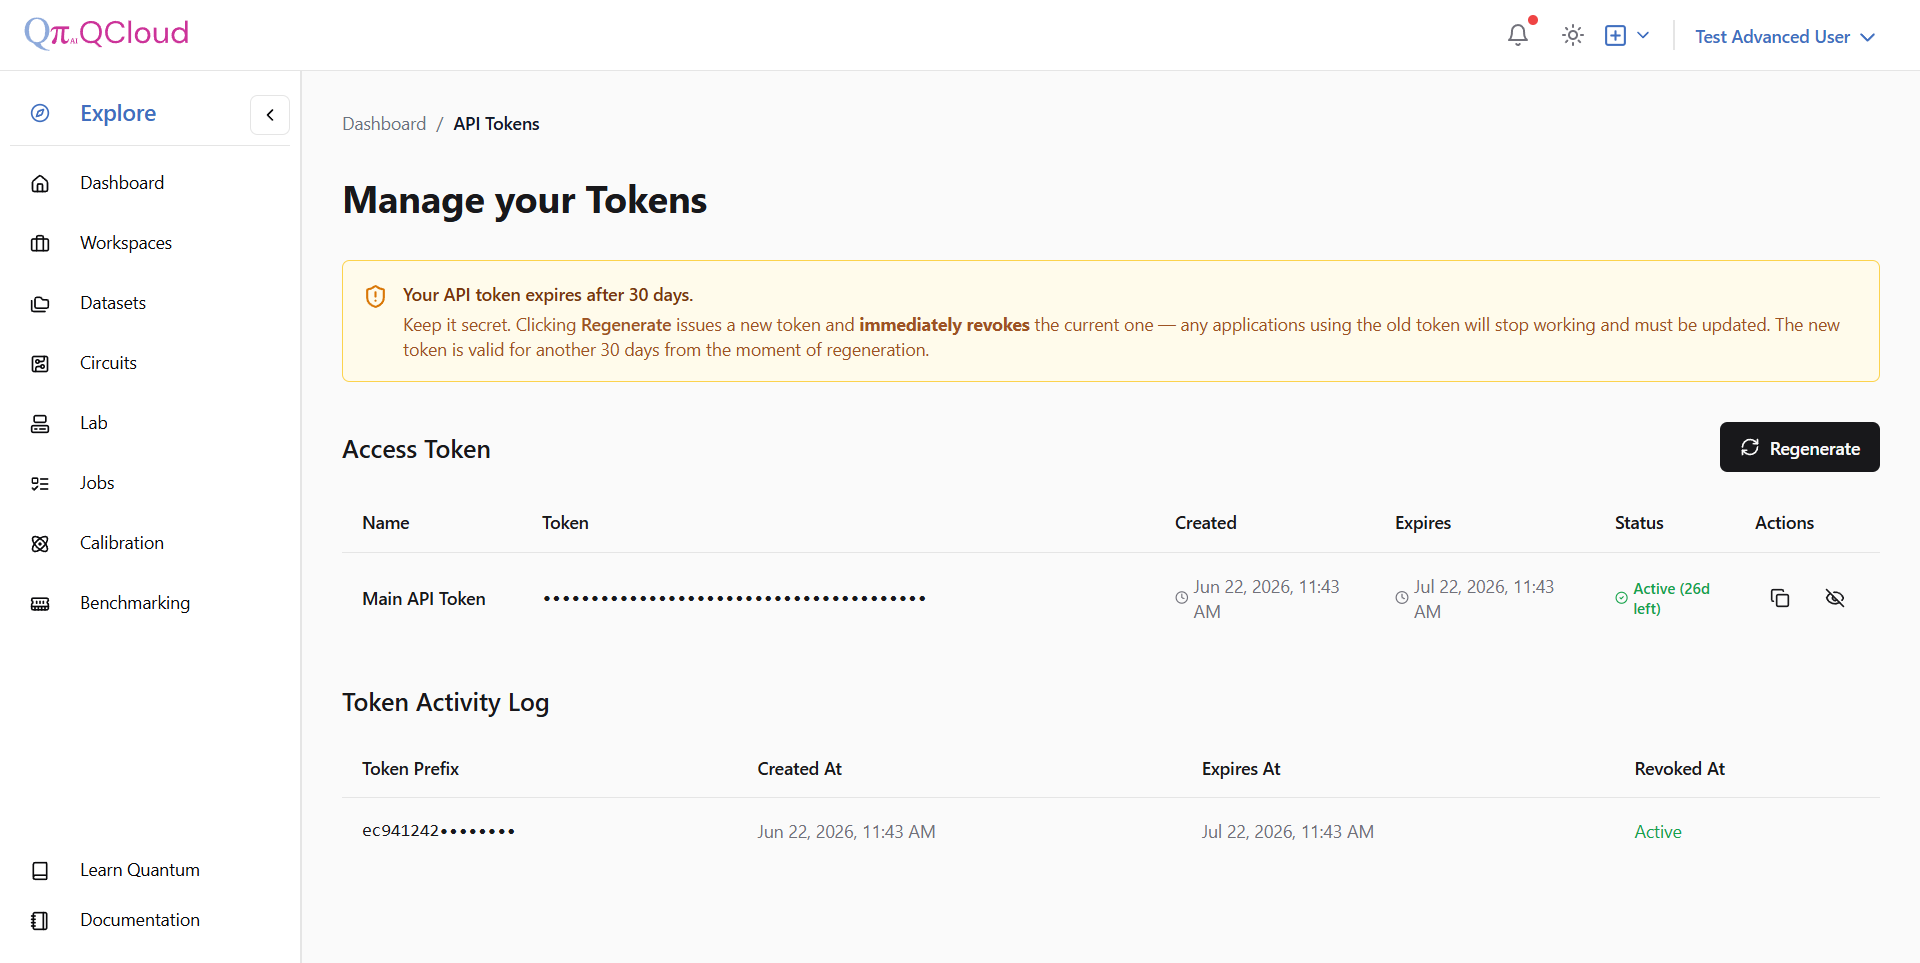

4. Create a new file named `qcloud.env`
5. Open `qcloud.env` and add the line `API_KEY="your_api_key_here"`

*Note: Never share or commit your `qcloud.env` file anywhere.*

> **Tip:** The path `"./qcloud.env"` in the code below is relative to the notebook's location. If you move the notebook, update the path accordingly.

The following cell will load your `API_KEY` from the `qcloud.env` file and authenticate you with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

### Verify API Key is Valid

Before running experiments, let's verify your API key has proper access:

In [2]:
is_valid = QpiAIQuantumAuth.verify_api_key()
if is_valid:
    print(" API key is valid and has proper access")
else:
    print(" API key validation failed - please check your API key")
    print("  Make sure you copied the correct API key from the QpiAI QCloud platform")

 API key is valid and has proper access


### List all available compute resources

To list all the compute resources associated with the current user.

In [3]:
QpiAIQuantumAuth.list_compute_resources()


Available Compute Resources:

Backend: QpiAI-Indus-1
  Device Name: QpiAI-Indus-1
  Usage Rate: 4 credits

Backend: QpiAI-QSV-Simulator
  Device Name: QpiAI-QSV-Simulator
  Usage Rate: 1 credits

Backend: QpiAI-QDM-Simulator
  Device Name: QpiAI-QDM-Simulator
  Usage Rate: 2 credits

Backend: QpiAI-QTN-Simulator
  Device Name: QpiAI-QTN-Simulator
  Usage Rate: 3 credits

Backend: QpiAI-QSV-Lite
  Device Name: QpiAI-QSV-Lite
  Usage Rate: 1 credits

Backend: QpiAI-QDM-Lite
  Device Name: QpiAI-QDM-Lite
  Usage Rate: 2 credits



### Example 1 : Build a Simple Circuit

Let's create a simple single-qubit circuit to demonstrate how the circuit builder works. We'll prepare a qubit in the plus state (|+⟩), which is an equal superposition of |0⟩ and |1⟩.

#### What is a Plus State?

The plus state is created by applying a Hadamard gate to a qubit initialized in the |0⟩ state:
- Initial state: |0⟩
- Apply Hadamard gate (H)
- Resulting state: |+⟩ = (|0⟩ + |1⟩)/√2


#### Understanding the Result

When we measure this circuit multiple times:
- Approximately 50% of measurements will yield |0⟩
- Approximately 50% of measurements will yield |1⟩

This demonstrates quantum superposition in action!

In [4]:
from qpiai_quantum import QuantumRegister, ClassicalRegister, Circuit
qreg = QuantumRegister(1, "q") # Define a quantum register with 1 qubits with name "q"
creg = ClassicalRegister(1, "c") # Define a classical register with 1 bits with name "c"
circuit = Circuit(qreg, creg) # Create a quantum circuit object with the above registers
circuit.h(0)  # Apply Hadamard gate on qubit 0
circuit.measure([0], [0])  # Measure qubit 0 into classical bit 0

### Draw the Circuit

Now that we've built our circuit, let's visualize it to understand its structure. The QpiAI SDK provides a convenient `.show()` method that renders a graphical representation of your quantum circuit.

```python
# Display the circuit diagram
circuit.show()
```

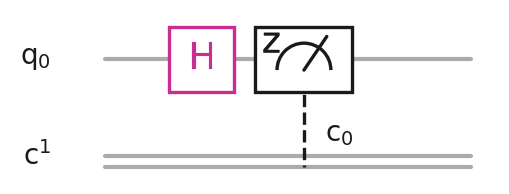

In [5]:
circuit.show()  # Draw the circuit

### Analyzing the Circuit Features

Once you've built your quantum circuit, it's useful to analyze its properties and characteristics. The QpiAI SDK provides several methods to inspect circuit details:

---


#### Circuit Depth

The depth represents the longest path of sequential gates in your circuit. It's a measure of how many time steps are required to execute the circuit.
```python
# Display the depth of the circuit  
circuit.depth()

In [6]:
circuit.depth()  # Display the depth of the circuit

1

#### Number of Qubits

This shows the total number of quantum bits (qubits) in your circuit.
```python
# Display the number of qubits  
circuit.num_qubits
```

In [7]:
circuit.num_qubits  # Get the number of qubits in the circuit

1

#### Number of Classical Bits

Classical bits store measurement results. This property shows how many classical bits are allocated in your circuit.
```python
# Display the number of classical bits  
circuit.num_clbits
```

In [8]:
circuit.num_clbits  # Get the number of classical bits in the circuit

1

#### List of Gates

Get a complete list of all quantum gates used in your circuit, helping you understand the operations being performed.
```python
# Display the list of all gates in the circuit  
circuit.list_gates()
```

In [9]:
circuit.list_gates()  # List all gates in the circuit

{'total_operations': 2,
 'total_gates': 1,
 'single_qubit_gates': 1,
 'two_qubit_gates': 0,
 'multi_qubit_gates': 0,
 'clifford_gates': 1,
 'non_clifford_gates': 0,
 'parametric_gates': 0,
 'measurements': 1,
 'barriers': 0,
 'gate_counts': {'H': 1, 'MEASURE': 1}}

### QCloud Execution: Create an Experiment in the UI

The examples below use **local simulators** (`QpiAI-QSV-Local`), which run entirely on your machine and **do not require** an experiment name.

To run on **qcloud simulators** or **real quantum hardware** (`QpiAI-Indus-1`), you must first create an experiment in the QpiAI web interface and pass its name via the `experiment_name` parameter.

#### Steps to Create an Experiment (QCloud Only):

1. **Register** and log in to the QpiAI QCloud platform at [https://qcloud.qpiai.tech](https://qcloud.qpiai.tech/)
2. **Navigate** to the `Workspace` section in the main dashboard > Create a respective `Workspace`.
3. **Create** a new Project inside the workspace
3. Inside the respective project, **Click** on "Create New Experiment" or the "+" button
4. **Enter** the experiment name - this must match the `experiment_name` parameter in your code
5. **Configure** additional settings as needed (optional)
6. **Save** the experiment

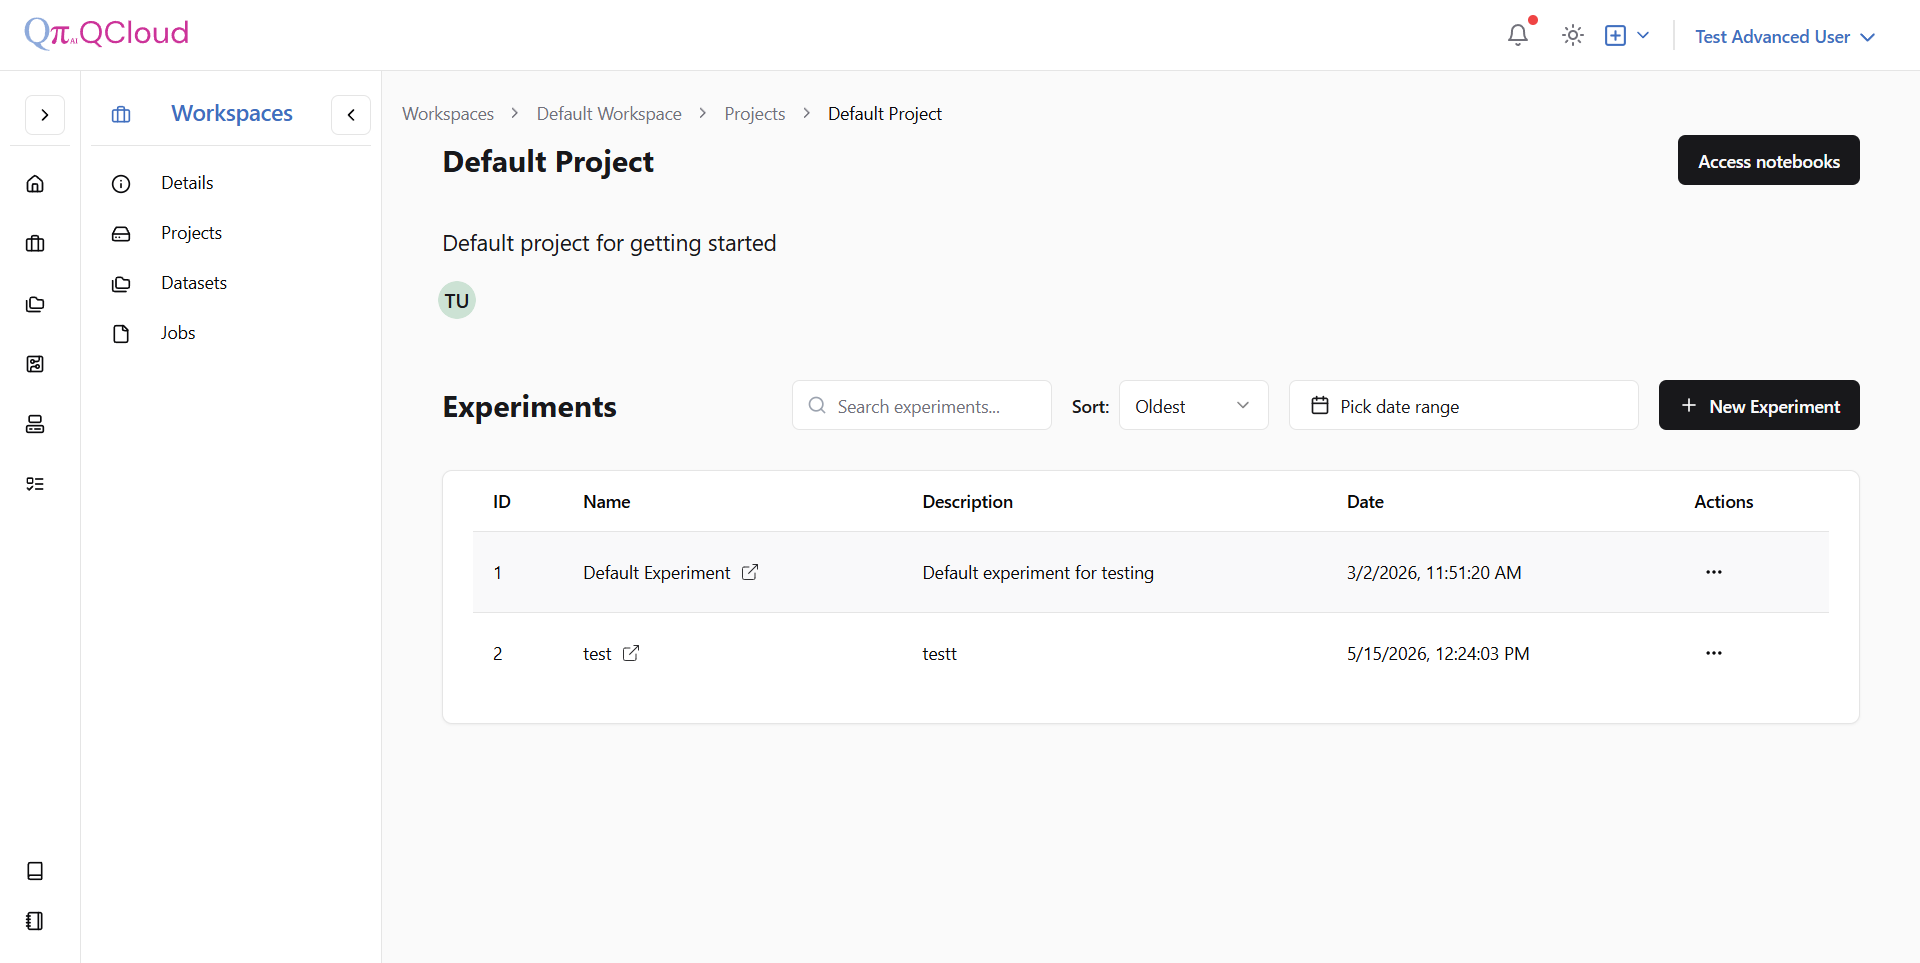
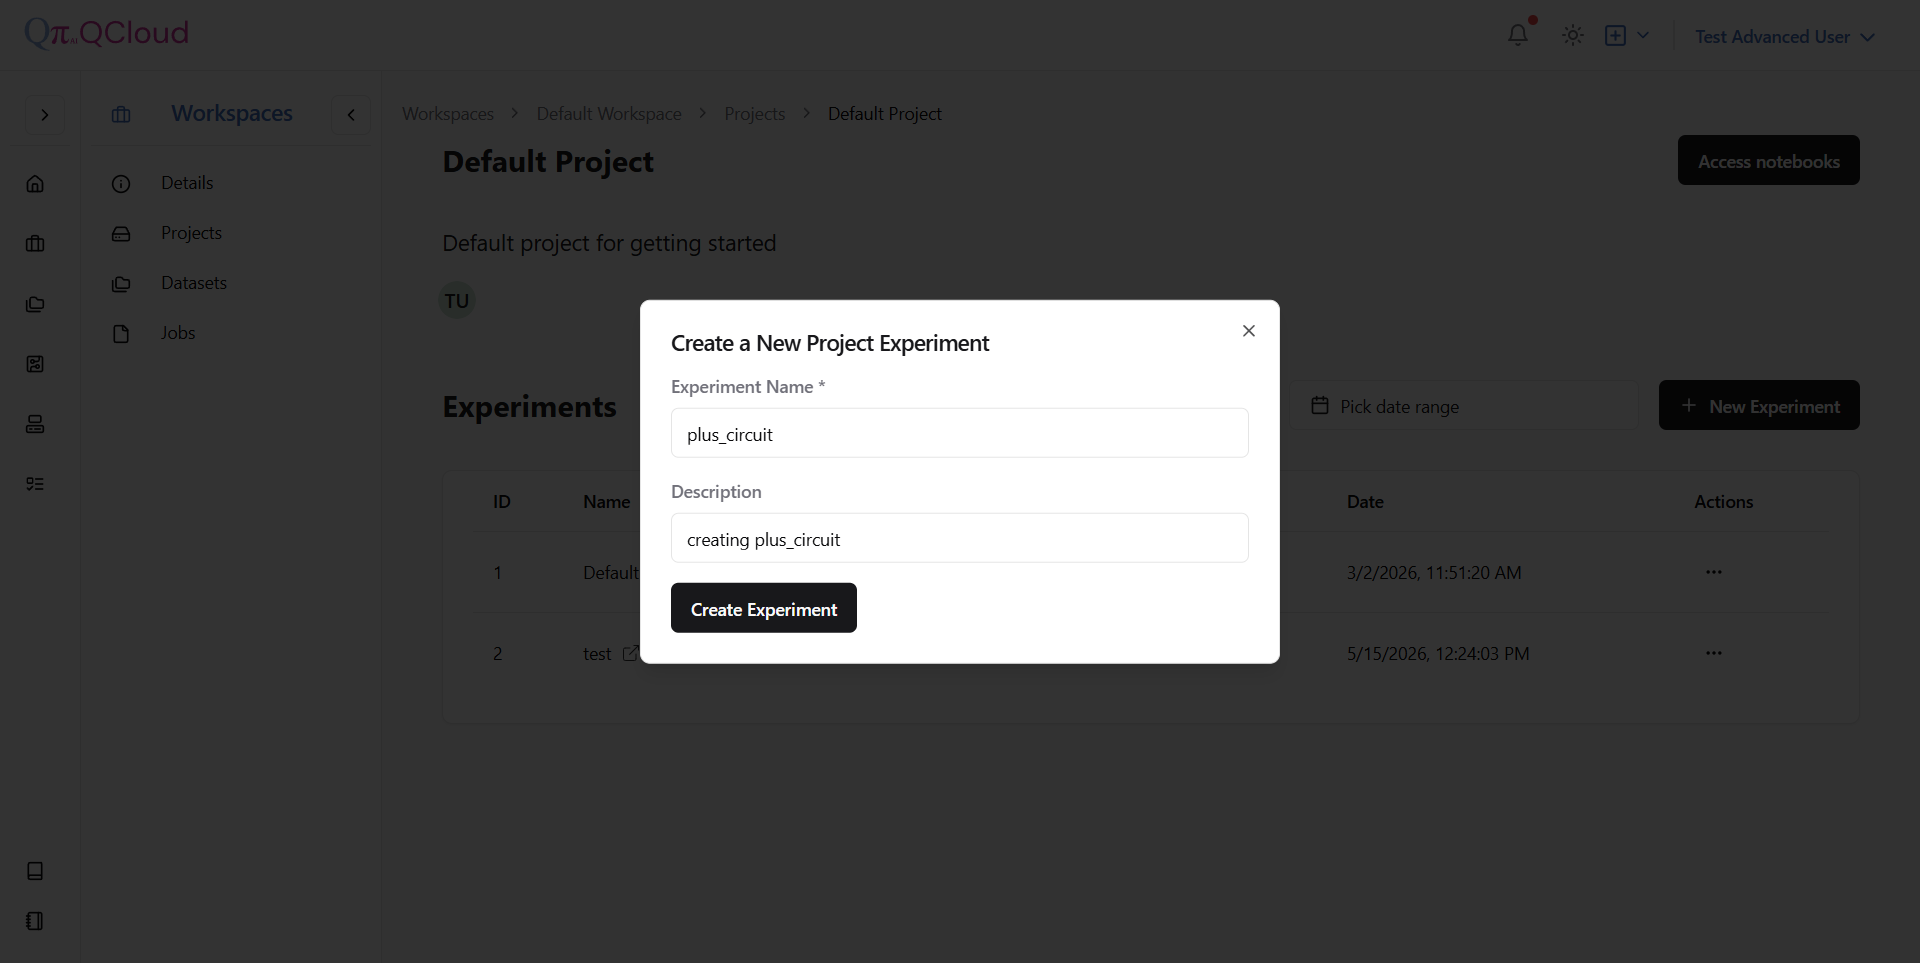

**Important Notes:**
- The experiment name in your code **must exactly match** the name in the UI (case-sensitive)
- This step is **only required for qcloud execution** — local simulators ignore the parameter

### Submit the Circuit to backend device

Now that we've built and analyzed our circuit, it's time to run it! The QpiAI SDK uses the `run` function to submit circuits to quantum simulators or real quantum hardware.

#### Understanding the Parameters

| Parameter | Description |
|-----------|-------------|
| `shots` | Number of times to run the circuit (default: 1024) |
| `experiment_name` | Required for QCloud execution — must match name created in the UI (optional for local simulators) |
| `device_name` | The target device: `"QpiAI-QSV-Local"` (local), `"QpiAI-QSV-Simulator"`, `"QpiAI-QDM-Simulator"`, `"QpiAI-QTN-Simulator"`, `"QpiAI-QSV-Lite"`, `"QpiAI-QDM-Lite"`, or `"QpiAI-Indus-1"` (real quantum hardware) |
| `reverse_bits` | Specify the qubit ordering: Big-endian (if `True`), else Little-endian (default: `False`) |
| `need_statevector` | Whether to return the statevector (default: `False`). Not available with density-matrix simulators. |
| `need_density_matrix` | Whether to return the density matrix (default: `False`) |

**Note:** Execution time varies based on circuit complexity and device availability.


In [10]:
res = circuit.run(shots=10000, device_name="QpiAI-QSV-Local")

##### To Extract the `Counts`

In [11]:
print(f"Counts : {res.get_counts()}")

Counts : {'0': 4956, '1': 5044}


##### To Extract the `probabilities`

In [12]:
print(f"Probabilities : {res.get_probabilities()}")

Probabilities : {'0': 0.4956, '1': 0.5044}


##### To Extract the `JOB ID`

In [13]:
print(f"JOB ID: {res.get_job_id()} and it's status {res.job_status}")

JOB ID: 0c43f9d0-6b8e-4574-bab4-85178f26cb12 and it's status Success


### Example 2 : Build a Two-Qubit Bell State Circuit

Let's create a two-qubit circuit that prepares the Bell state |Ψ+⟩ = (|01⟩ + |10⟩)/√2.

#### What is a Bell State?

Bell states are maximally entangled two-qubit states. In this example we prepare |Ψ+⟩ using:
1. Apply an X gate to qubit 1 (flip it from |0⟩ to |1⟩)
2. Apply a Hadamard gate to qubit 0 (create superposition)
3. Apply a CNOT gate with qubit 0 as control and qubit 1 as target (entangle)


#### Understanding the Result

When we measure this circuit multiple times:
- Approximately 50% of measurements will yield |01⟩
- Approximately 50% of measurements will yield |10⟩

This demonstrates quantum entanglement in action!


In [14]:
bell_circuit = Circuit(2, 2) # Create a 2-qubit, 2-classical-bit circuit
bell_circuit.x(1)  # Apply X gate on qubit 1 to create |10> state
bell_circuit.barrier(0,1)  # Apply barrier on qubits 0 and 1
bell_circuit.h(0)  # Apply Hadamard gate on qubit 0
bell_circuit.cx(0,1) # Apply CNOT gate with control qubit 0 and target qubit 1
bell_circuit.measure([0,1], [0,1])  # Measure qubit 0 and 1 into classical bits 0 and 1 respectively

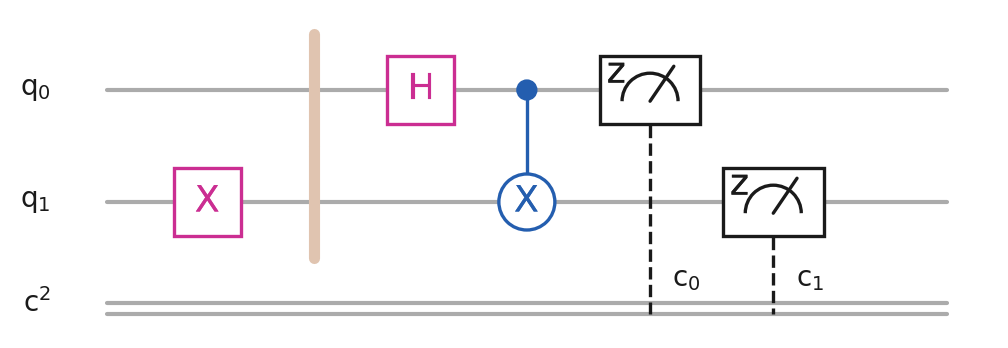

In [15]:
bell_circuit.show()  # Draw the circuit

To extract counts in **big-endian** format (the default is **little-endian**), use `reverse_bits=True`.

```python
res = circuit.run(
    reverse_bits=True
)


In [16]:
# By Default : qpiai_quantum uses Little-endian Format
res_l = bell_circuit.run(shots=10000, device_name='QpiAI-QSV-Local')
print(f"Little-endian counts : {res_l.get_counts()}")
res_b = bell_circuit.run(shots=10000, device_name='QpiAI-QSV-Local', reverse_bits=True)
print(f"Big-endian counts : {res_b.get_counts()}")

Little-endian counts : {'01': 4956, '10': 5044}
Big-endian counts : {'10': 5039, '01': 4961}


### Analyzing Execution Results

Once your circuit execution is complete, you can extract and visualize the measurement results using the built-in methods provided by the QpiAI SDK.

#### Visualizing Results

The SDK provides a convenient plotting method to visualize your measurement results as a histogram:

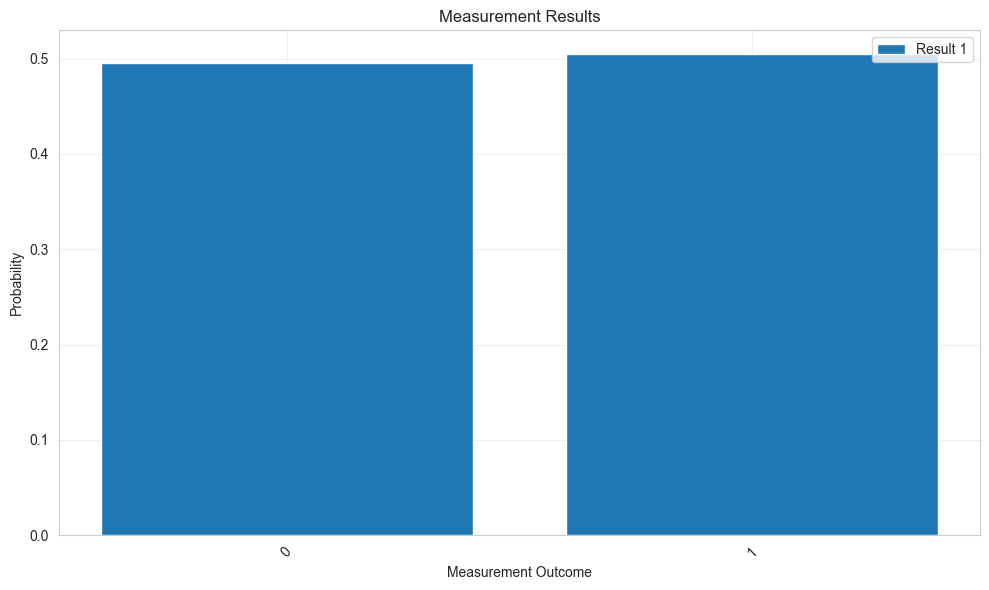

In [17]:
res.plot() # Plot the measurement results as a histogram

### Comparison Plot Features on Histogram

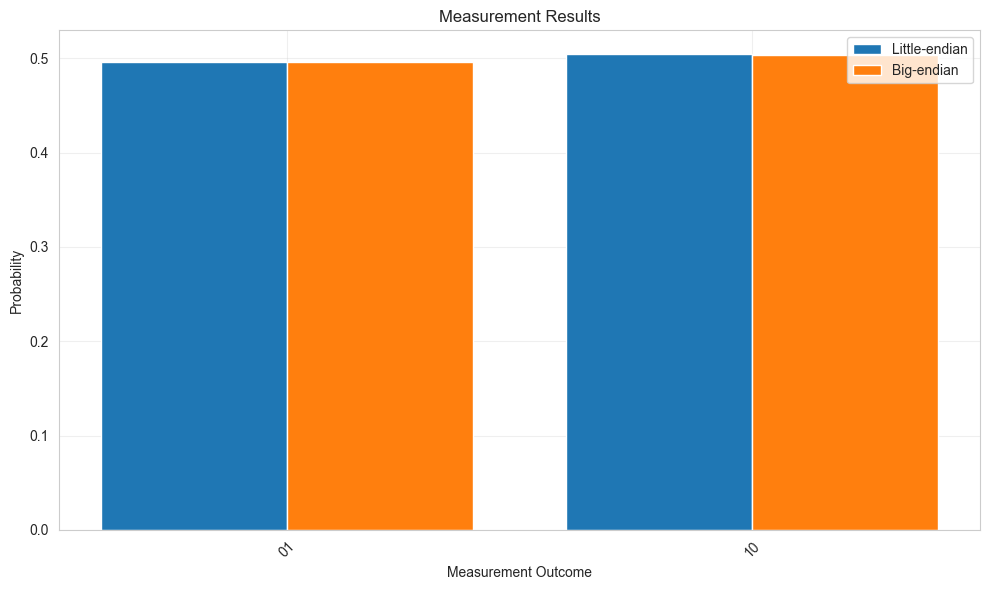

In [18]:
# Plot comparison between Little-endian and Big-endian results using the custom labels
res_l.plot(res_b, labels=['Little-endian', 'Big-endian'])

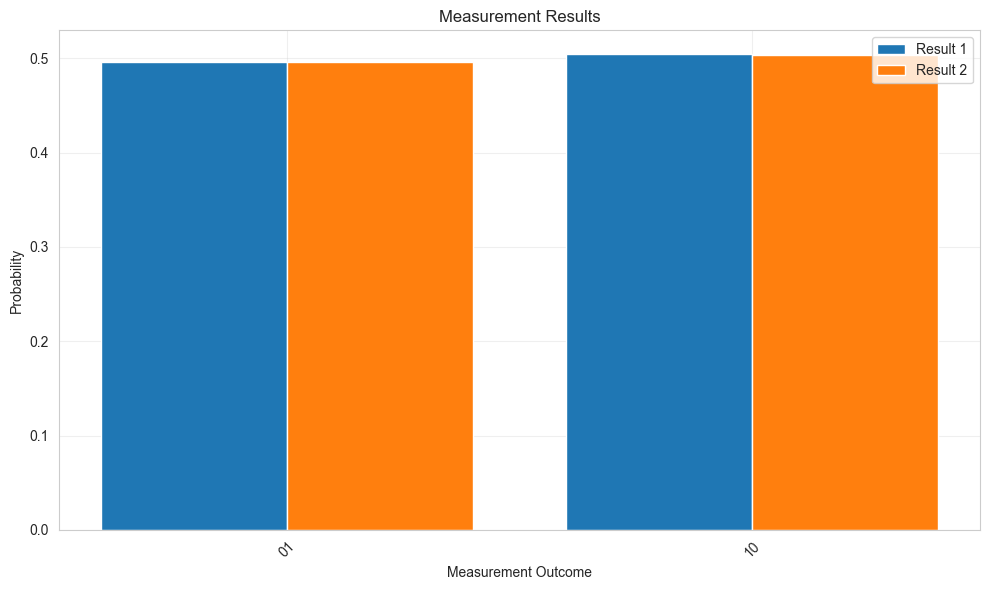

In [19]:
# Plot comparison between Little-endian and Big-endian results by default labels
res_l.plot(res_b)

### Example 3: Generate Random Quantum Circuits

The `RandomCircuitGenerator` is a powerful utility for creating random quantum circuits with customizable parameters. This is particularly useful for benchmarking quantum hardware, testing quantum algorithms, and exploring the quantum circuit space.

#### Importing the Generator
```python
from qpiai_quantum.circuit import RandomCircuitGenerator
```

#### Class Parameters

The `RandomCircuitGenerator` provides extensive customization options:

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `num_qubits` | int | Required | Number of qubits in the circuit |
| `depth` | int | Required | Depth (number of layers) of the random circuit |
| `allow_parametric` | bool | `True` | Enable parametric gates (with rotation angles) |
| `single_qubit_gates` | List[str] | `None` | List of single-qubit gates to use (e.g., `['h', 'x', 'y', 'z']`) |
| `parametric_single_qubit_gates` | List[str] | `None` | Parametric single-qubit gates (e.g., `['rx', 'ry', 'rz']`) |
| `two_qubit_gates` | List[str] | `None` | Two-qubit gates to use (e.g., `['cx', 'cz', 'swap']`) |
| `parametric_two_qubit_gates` | List[str] | `None` | Parametric two-qubit gates (e.g., `'rrz'`) |
| `three_qubit_gates` | List[str] | `None` | Three-qubit gates (e.g., `['ccx', 'toffoli']`) |
| `add_measurements` | bool | `True` | Automatically add measurements at the end |
| `single_qubit_probability` | float | `0.6` | Probability of selecting single-qubit gates (60%) |
| `two_qubit_probability` | float | `0.3` | Probability of selecting two-qubit gates (30%) |
| `parametric_probability` | float | `0.3` | Probability of using parametric gates (30%) |


#### Advanced Custom Configuration

Create a circuit with specific gate sets and probabilities:
```python
# Generate a circuit with custom gate selections
generator = RandomCircuitGenerator(
    num_qubits=5,
    depth=10,
    allow_parametric=True,
    single_qubit_gates=['h', 'x', 'y', 'z', 's', 't'],
    parametric_single_qubit_gates=['rx', 'ry', 'rz'],
    two_qubit_gates=['cx', 'cz', 'swap'],
    parametric_two_qubit_gates=['rzz'],
    three_qubit_gates=['ccx'],
    add_measurements=True,
    single_qubit_probability=0.5,
    two_qubit_probability=0.4,
    parametric_probability=0.2
)

# Generate the random circuit
custom_circuit = generator.generate()

```

#### Understanding Gate Probabilities

The probability parameters determine the gate distribution:

- **Single-qubit probability (0.6)**: 60% chance of selecting a single-qubit gate
- **Two-qubit probability (0.3)**: 30% chance of selecting a two-qubit gate
- **Remaining probability (0.1)**: Goes to three-qubit gates (if available)
- **Parametric probability (0.3)**: 30% of selected gates will be parametric variants

**Note:** Probabilities for single and two-qubit gates should sum to ≤ 1.0

#### Common Gate Types

**Single-Qubit Gates:**
- `h` - Hadamard
- `x`, `y`, `z` - Pauli gates
- `s`, `t` - Phase gates
- `sx` - √X gate
- `rx`, `ry`, `rz` - Rotation gates (parametric)

**Two-Qubit Gates:**
- `cx` - CNOT (controlled-X)
- `cz` - Controlled-Z
- `swap` - SWAP gate
- `rzz` - Controlled rotation gates (parametric)

**Three-Qubit Gates:**
- `ccx` - Toffoli (doubly-controlled-X)


Random circuits are an essential tool in the quantum computing toolkit. Let's generate one and execute it!

In [20]:
from qpiai_quantum.circuit import RandomCircuitGenerator

generator = RandomCircuitGenerator(
    num_qubits=3,
    depth=5,
    allow_parametric=True,
    single_qubit_gates=['h', 'x', 'y', 'z', 's', 't'],
    parametric_single_qubit_gates=['rx', 'ry', 'rz'],
    two_qubit_gates=['cx', 'cz', 'swap'],
    parametric_two_qubit_gates=['rzz'],
    three_qubit_gates=['ccx'],
    add_measurements=True,
    single_qubit_probability=0.5,
    two_qubit_probability=0.4,
    parametric_probability=0.2
)

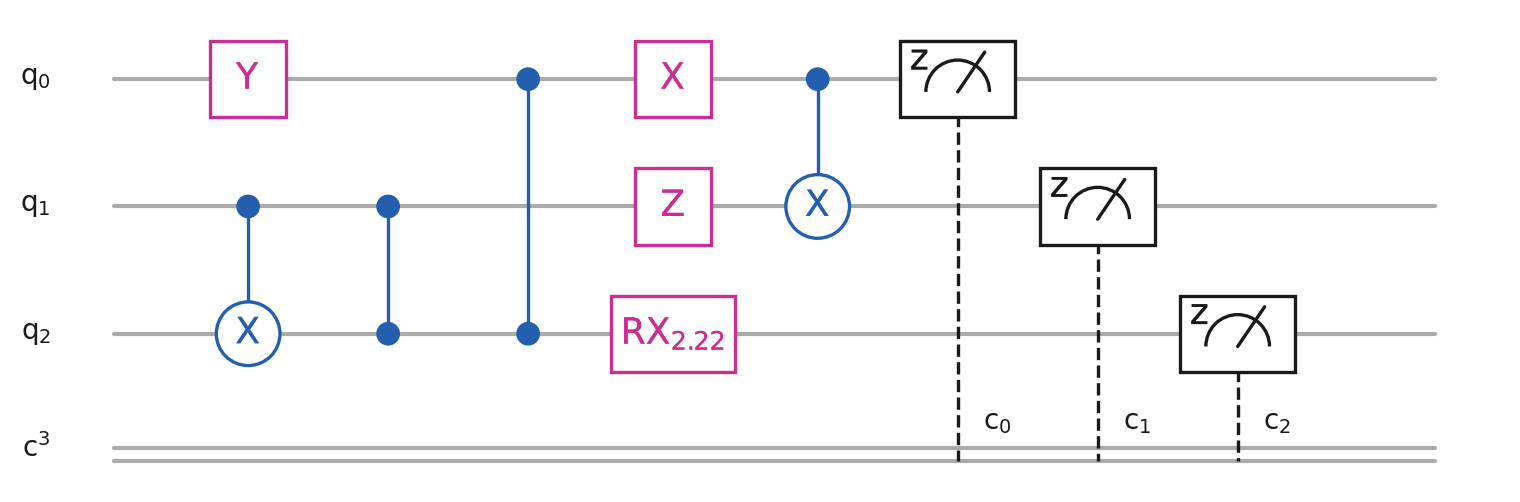

In [21]:
rand_circ = generator.generate()
rand_circ.show()

### Execute the Circuit

Now that we've built and analyzed our circuit, it's time to run it! The QpiAI SDK uses the `run` function to submit circuits to quantum simulators or real quantum hardware.

In [22]:
res = rand_circ.run(shots=10000, device_name='QpiAI-QSV-Local')
print("Counts:", res.get_counts())

Counts: {'011': 8004, '111': 1996}


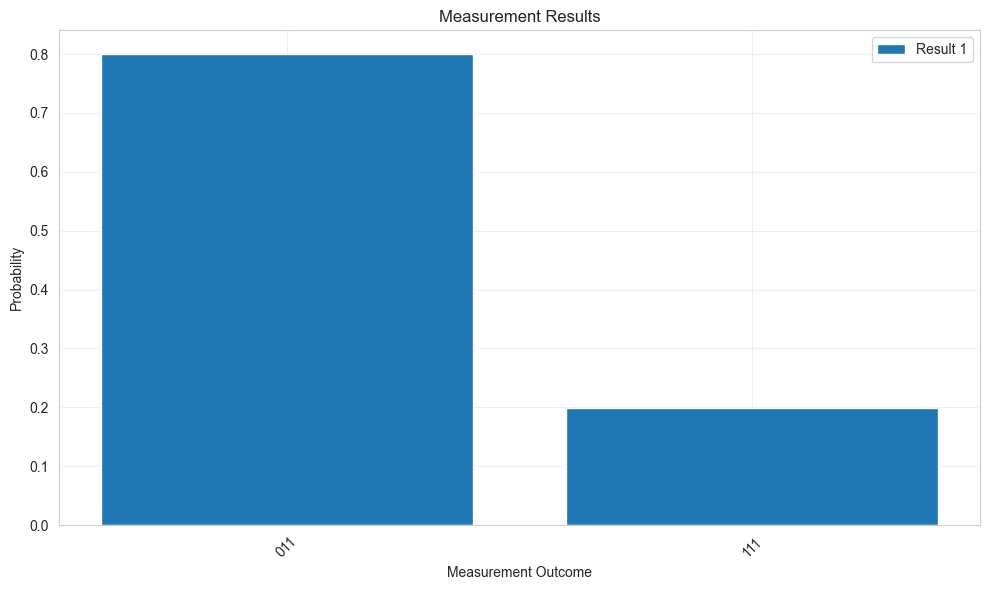

In [23]:
res.plot() # Plot the measurement results as a histogram

You can control various aspects of this circuit generator by tweaking the parameters. See the complete documentation for full detail.

### Intermediate Representations of a Circuit

You can export the circuit object in various intermediate representations like `qasm`, `JSON` etc.


#### From `Circuit()` object to `QASM` code 

```python

Circuit.to_qasm()
```

Let's export this randomly generated circuit to QASM format.

In [24]:
qasm = rand_circ.to_qasm()
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
y q[0];
cx q[1], q[2];
swap q[1], q[2];
swap q[0], q[2];
z q[1];
rx(2.218474004820076) q[2];
x q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


#### From `Circuit()` object to `JSON` format 

```python

Circuit.to_json()
```

Let's export this randomly generated circuit to JSON format.

In [25]:
from pprint import pprint
json_data = rand_circ.to_json()
pprint(json_data)

{'cregs': [{'bits': [{'index': 0, 'register': 'c'},
                     {'index': 1, 'register': 'c'},
                     {'index': 2, 'register': 'c'}],
            'name': 'c',
            'size': 3,
            'type': 'Classical'}],
 'evolve': [{'gate_name': 'Y',
             'operation_type': 'n_qubit_non_parametric',
             'qubits': [0]},
            {'gate_name': 'CX',
             'operation_type': 'n_qubit_non_parametric',
             'qubits': [1, 2]},
            {'gate_name': 'SWAP', 'operation_type': 'swap', 'qubits': [1, 2]},
            {'gate_name': 'SWAP', 'operation_type': 'swap', 'qubits': [0, 2]},
            {'gate_name': 'Z',
             'operation_type': 'n_qubit_non_parametric',
             'qubits': [1]},
            {'gate_name': 'RX',
             'operation_type': 'n_qubit_parametric',
             'params': [2.218474004820076],
             'qubits': [2]},
            {'gate_name': 'X',
             'operation_type': 'n_qubit_non_parametric',
 

## Job Management and History

Let's explore some of the job management capabilities:

In [26]:
from qpiai_quantum import JobManager
job_manage = JobManager()
job_history = job_manage.get_job_history(period="monthly")

print("=== Recent Jobs (Page 1) ===")
total = job_history["pagination"]["total"]
page_size = job_history["pagination"].get("page_size", 20)
jobs_on_page = job_history["jobs"]

print(f"Total jobs: {total}")
print(f"Showing first {len(jobs_on_page)} jobs (page 1, page_size={page_size}):")

completed_jobs = [job for job in jobs_on_page if job["status"] == "Success"]
failed_jobs = [job for job in jobs_on_page if job["status"] == "Failed"]
running_jobs = [job for job in jobs_on_page if job["status"] == "Running"]

print(f"  Completed (this page): {len(completed_jobs)}")
print(f"  Failed (this page): {len(failed_jobs)}")
print(f"  Running (this page): {len(running_jobs)}")

print("\nLast 5 completed jobs on this page:")
for job in completed_jobs[-5:]:
    execution_time = job.get("execution_metrics", 0) / 1000
    print(f"  • {job['id'][:8]}... - {execution_time:.2f}s - {job.get('credits_used', 0)} credits")


=== Recent Jobs (Page 1) ===
Total jobs: 324
Showing first 20 jobs (page 1, page_size=20):
  Completed (this page): 20
  Failed (this page): 0
  Running (this page): 0

Last 5 completed jobs on this page:
  • 722771a7... - 0.00s - 1 credits
  • 883afc19... - 0.00s - 1 credits
  • d4273f91... - 0.00s - 1 credits
  • 241c6ff9... - 0.00s - 1 credits
  • dafea8ce... - 0.00s - 1 credits



---

**Thank you for learning with QpiAI!**

In [27]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.32
